<a href="https://colab.research.google.com/github/HEMA-N2007/hemanirmal_n2007/blob/main/GENAIex8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q diffusers transformers accelerate safetensors

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GPU is not available.
Please enable GPU in Colab:
Runtime → Change runtime type → T4 GPU


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/30 [00:00<?, ?it/s]

Image generated successfully!
Saved as: generated_city.png


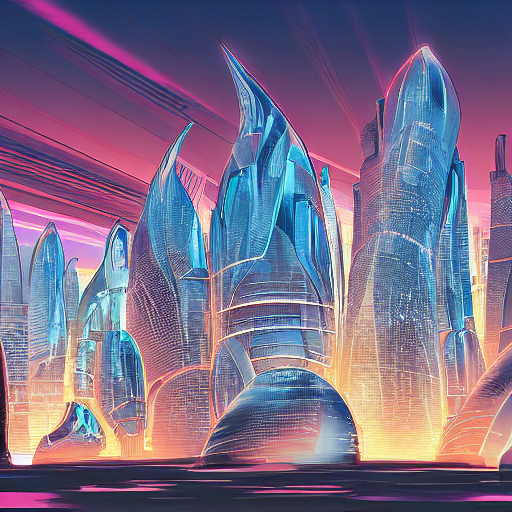

In [ ]:
# --------------------------------------------------
# 1. Import Required Libraries
# --------------------------------------------------

import torch
from diffusers import StableDiffusionPipeline


# --------------------------------------------------
# 2. Check GPU Availability
# --------------------------------------------------

if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
    print("GPU is available.")
    print("Using device:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    dtype = torch.float32
    print("GPU is not available.")
    print("Please enable GPU in Colab:")
    print("Runtime → Change runtime type → T4 GPU")


# --------------------------------------------------
# 3. Load Stable Diffusion Model
# --------------------------------------------------

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    safety_checker=None
)

pipe = pipe.to(device)


# --------------------------------------------------
# 4. Generate Image
# --------------------------------------------------

prompt = "A futuristic city skyline at sunset, digital art, highly detailed"

image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]


# --------------------------------------------------
# 5. Save Image
# --------------------------------------------------

image.save("generated_city.png")

print("Image generated successfully!")
print("Saved as: generated_city.png")


# --------------------------------------------------
# 6. Display Image in Colab
# --------------------------------------------------

display(image)